In [296]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

score
0    157739
1      3755
2       127
3        17
4         4
Name: count, dtype: int64


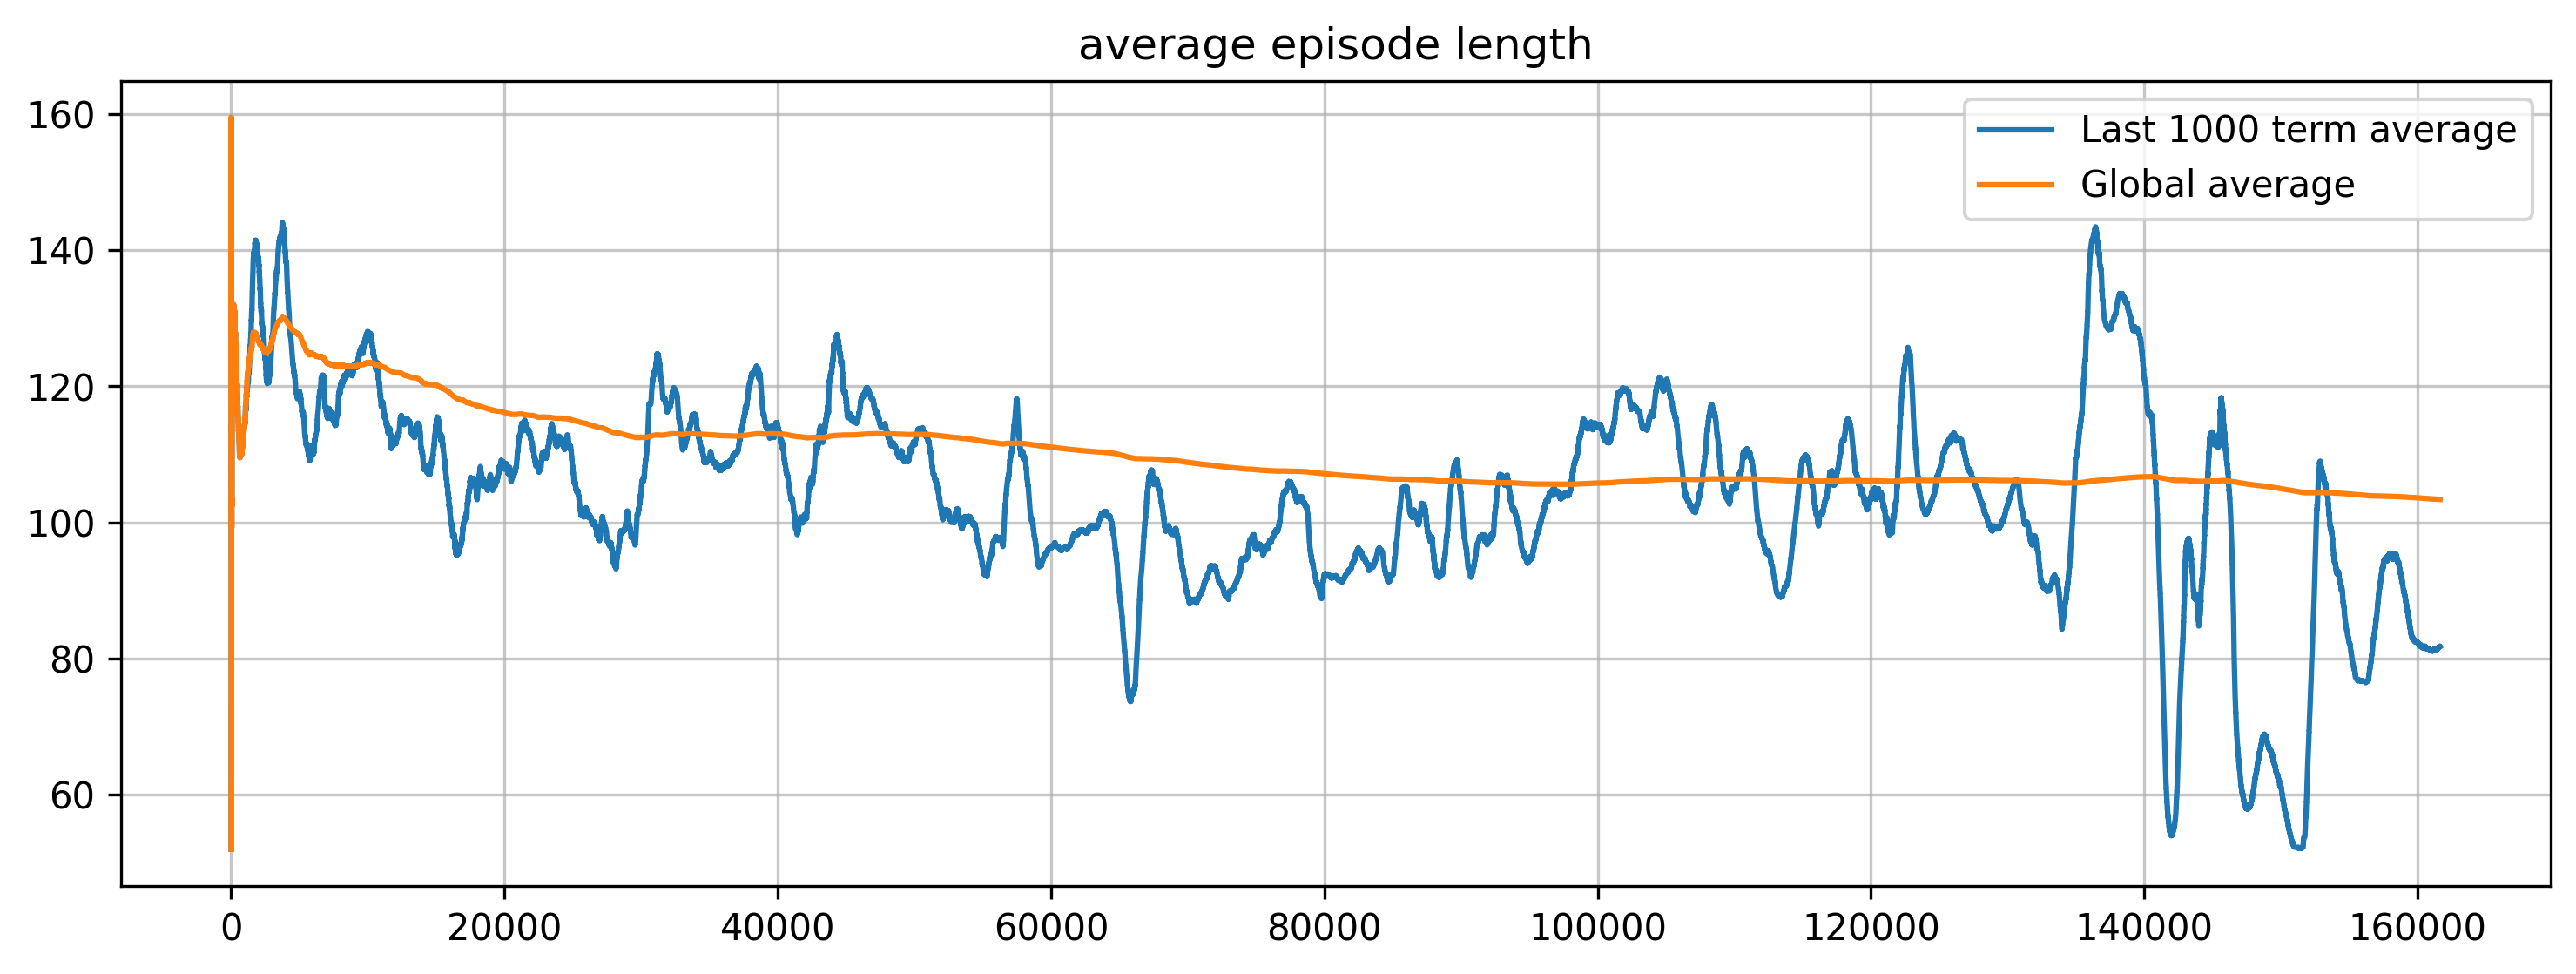

In [2727]:
df = pd.read_csv('log1.csv')
print(df['score'].value_counts())
# print(df['episode_length'].value_counts())
plot_avg_ep(1000)

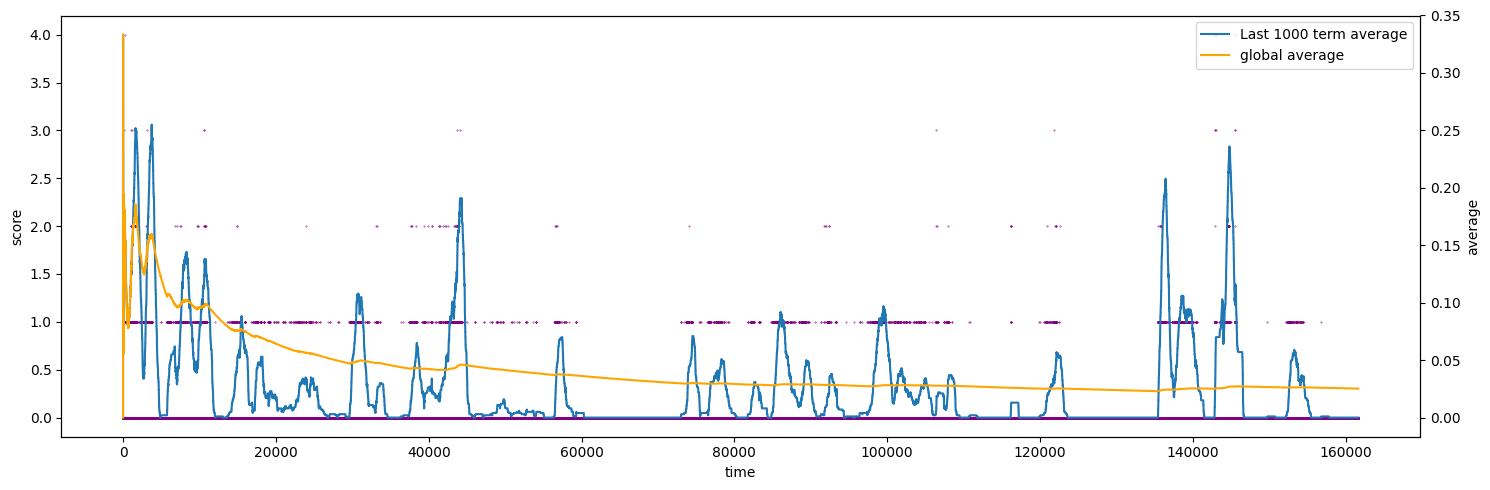

In [2728]:
fig, ax1 = plt.subplots()

fig.set_size_inches((15, 5))
# fig.set_dpi(300)

ax1.set_xlabel('time')
ax1.set_ylabel('score')
ax1.scatter(np.arange(df.shape[0]), df['score'], label='Scores', s=0.1, color='purple')

ax2 = ax1.twinx()
ax2.set_ylabel('average')
ax2.plot(df['score'].rolling(window=1000, min_periods=1).mean(), label='Last 1000 term average')
ax2.plot((df['score'].cumsum()/np.arange(1, df.shape[0]+1)), label='global average', color='orange')
ax2.legend()

fig.tight_layout()
plt.show()
plt.close()

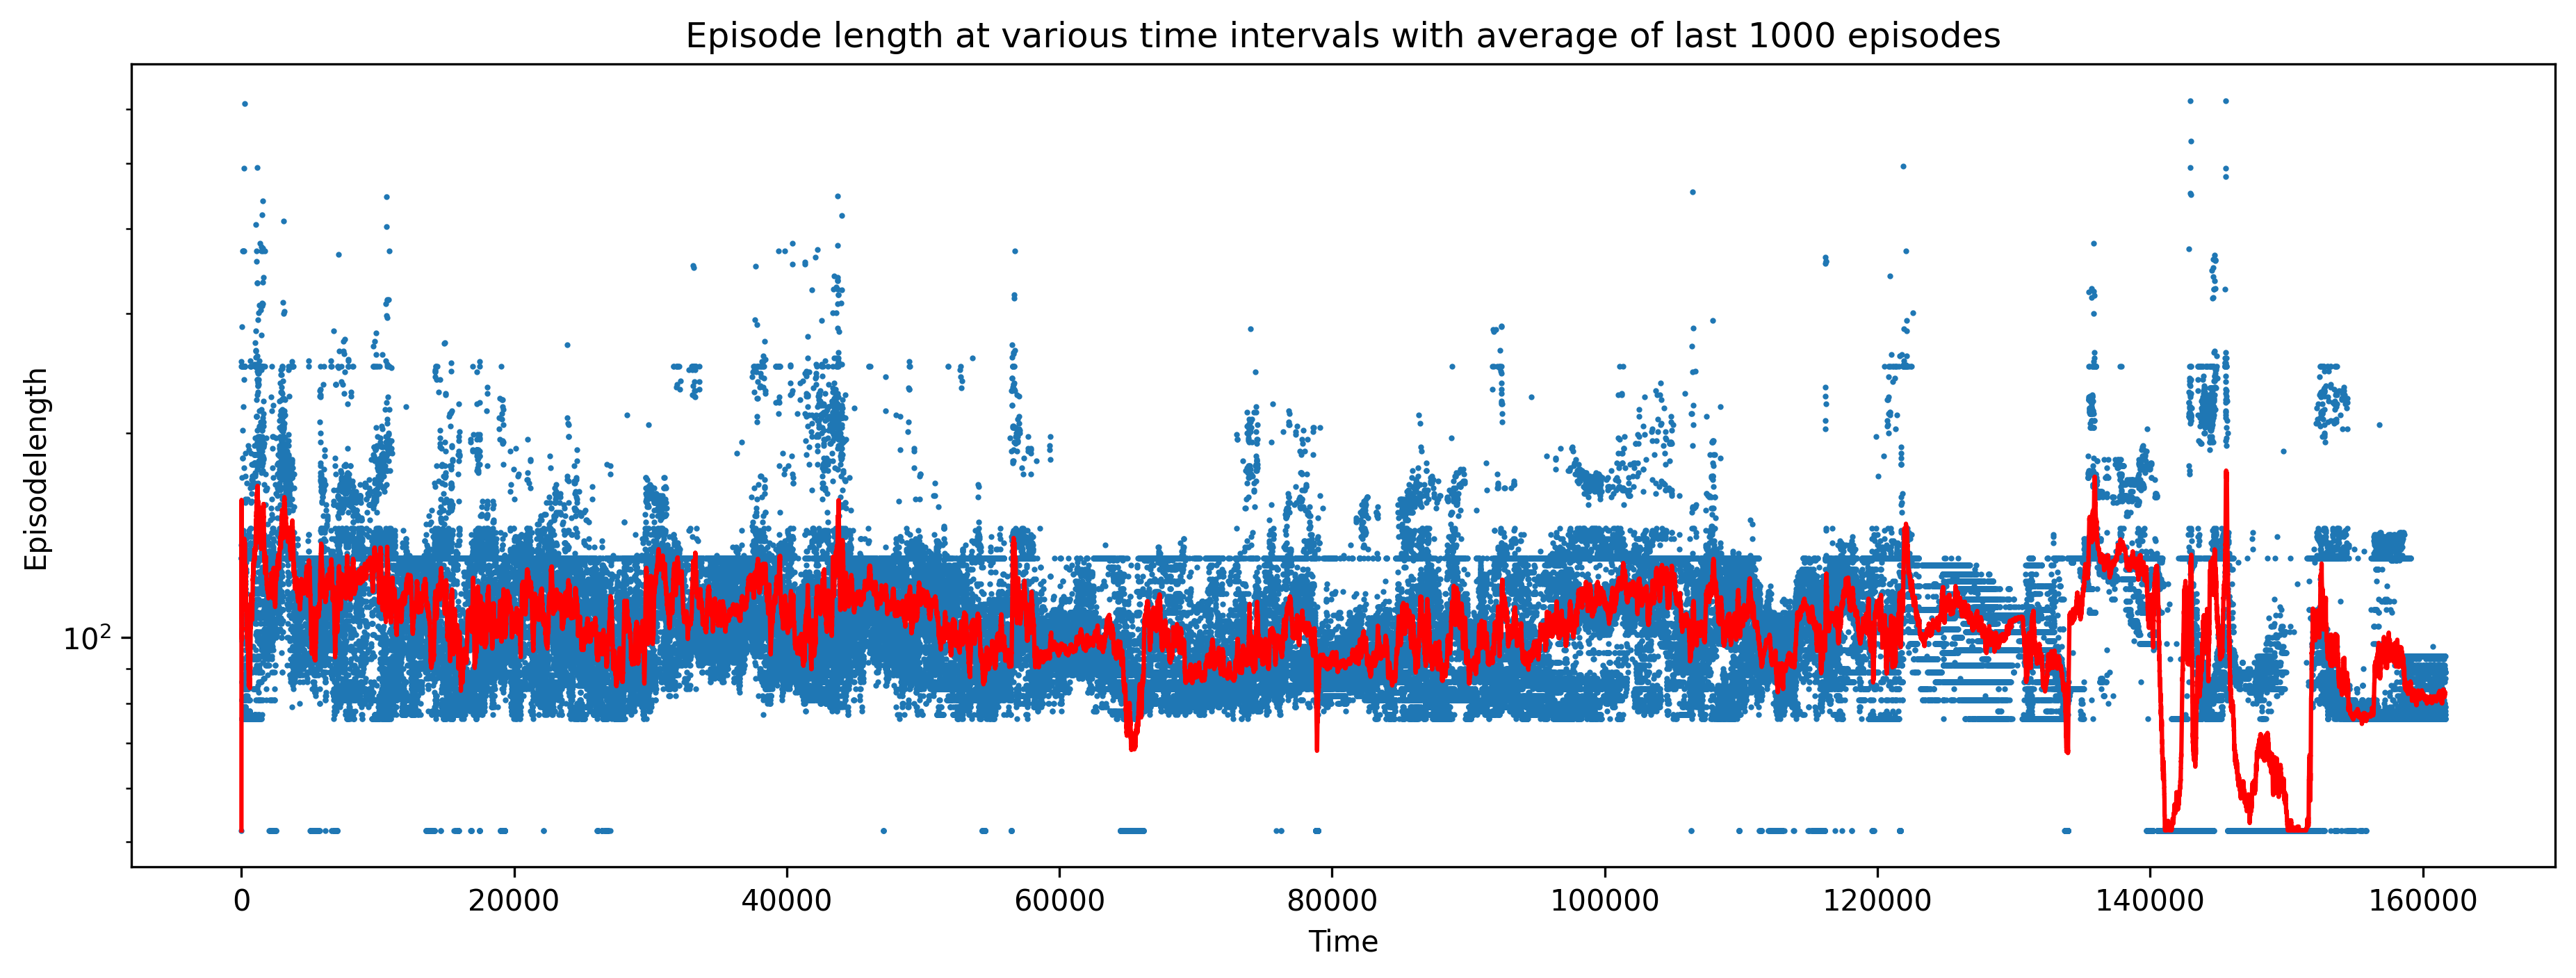

In [2729]:
fig, ax1 = plt.subplots()
fig.set_size_inches((15, 5))
fig.set_dpi(300)
ax1.scatter(np.arange(df.shape[0]), df['episode_length'], s=1)
ax1.set_xlabel('Time')
ax1.set_yscale('log')
ax1.set_ylabel('Episodelength')
ax1.set_title('Episode length at various time intervals with average of last 1000 episodes')
ax1.plot(df['episode_length'].rolling(window=100, min_periods=1).mean(), color='red')

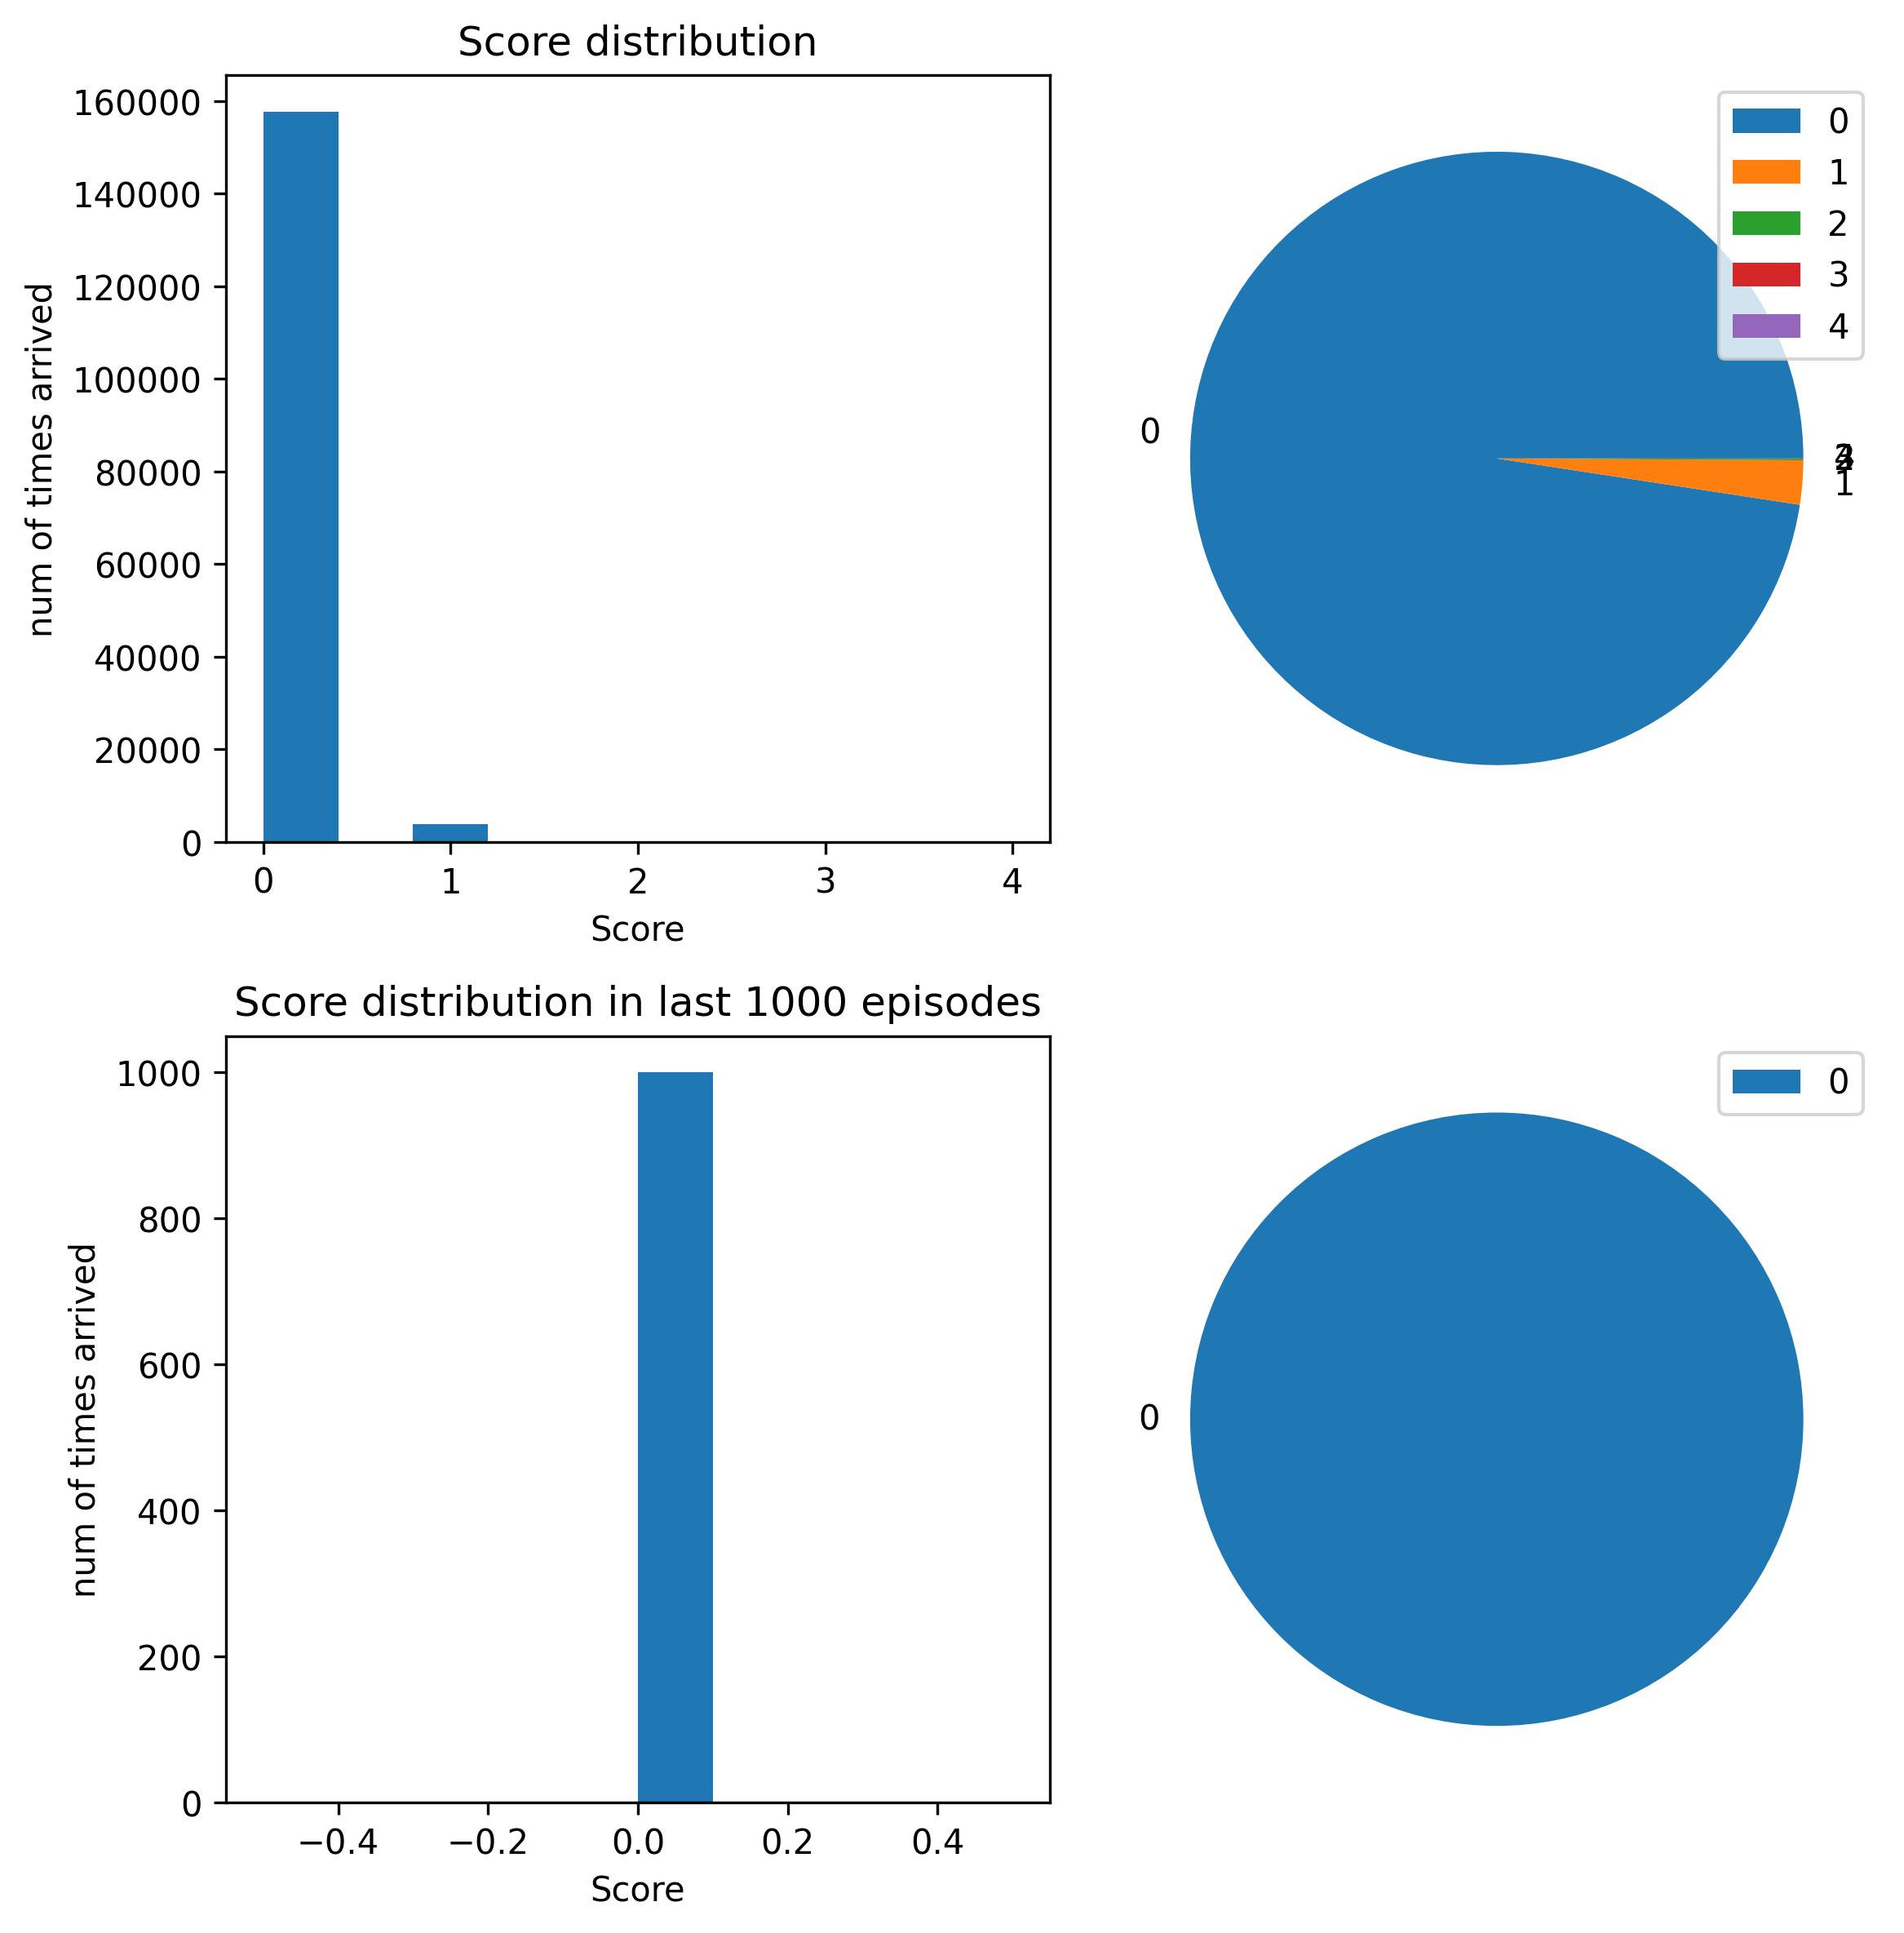

In [2730]:
# plotting the score distribution
fig, ax = plt.subplots(2, 2)
fig.set_size_inches((8,8))
fig.set_dpi(300)

(ax1, ax2), (ax3, ax4) = ax

ax1.hist(df['score'])
ax1.set_xlabel('Score')
ax1.set_ylabel('num of times arrived')
ax1.set_title('Score distribution')

labels = df['score'].value_counts().index
freq = df['score'].value_counts().values
ax2.pie(freq, labels=labels)
ax2.legend()

ax3.hist(df['score'][-1000:])
ax3.set_xlabel('Score')
ax3.set_ylabel('num of times arrived')
ax3.set_title('Score distribution in last 1000 episodes')

labels = df['score'][-1000:].value_counts().index
freq = df['score'][-1000:].value_counts().values
ax4.pie(freq, labels=labels)
ax4.legend()

fig.tight_layout()
plt.show()
plt.close()

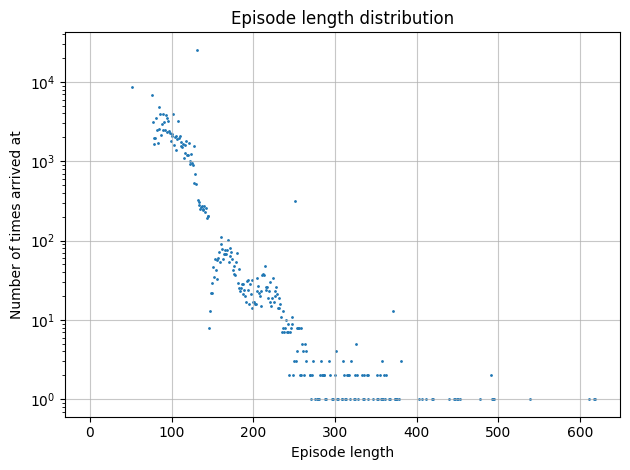

In [2731]:
fig, ax = plt.subplots()

k=0
n=df.shape[0]

x_ax = np.zeros(df['episode_length'].max()+1)
x_ax[df['episode_length'][k:n].value_counts().index] = df['episode_length'][k:n].value_counts().values
ax.scatter(np.arange(df['episode_length'][k:n].max()+1), x_ax, s=1)

ax.grid(alpha=0.7)
ax.set_yscale('log')
ax.set_xlabel('Episode length')
ax.set_ylabel('Number of times arrived at')
ax.set_title('Episode length distribution')
fig.tight_layout()

plt.show()
plt.close()

In [2110]:
def plot_avg_ep(x=1000):
    fig, ax = plt.subplots()
    fig.set_dpi(300)
    fig.set_size_inches((12,4))
    ax.grid(alpha=0.7)
    ax.set_title('average episode length')
    ax.plot(df['episode_length'].rolling(window=x, min_periods=1).mean(), label='Last 1000 term average')
    ax.plot(df['episode_length'].cumsum()/np.arange(1, df.shape[0]+1), label='Global average')
    ax.legend()
    plt.show()